## 1. Setup

Import the libraries used throughout the notebook together with the two `simpest` model interfaces: `simplace` (crop growth) and `franchestyn` (disease and calibration).

In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import simpest.models.simplace as simplace
import simpest.models.franchestyn as franchestyn

In [2]:
def plot_weather(df, columns, titles, colors=None, filter_dict=None):
    """
    Plots weather data with minimal configuration.
    
    Parameters:
    - df: DataFrame
    - columns: List of column names or lists of column names [['Tmin', 'Tmax'], 'Irradiation', ...]
    - titles: List of strings for subplot titles
    - colors: List of colors for each plot (optional)
    - filter_dict: Dict mapping column names to a filter condition string (optional)
                   e.g., {'Precipitation': '> 0'}
    """
    sns.set_theme()
    num_plots = len(columns)
    num_rows = math.ceil(num_plots / 2)
    
    fig, axes = plt.subplots(num_rows, 2, figsize=(15, 5 * num_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(columns):
        ax = axes[i]
        color = colors[i] if colors and i < len(colors) else None
        
        # 1. Handle Filtering if applicable
        plot_df = df
        if filter_dict:
            # Check if current col (or first element if it's a list) has a filter
            lookup_col = col[0] if isinstance(col, list) else col
            if lookup_col in filter_dict:
                plot_df = df.query(f"{lookup_col} {filter_dict[lookup_col]}")
        
        # 2. Plotting Logic
        if isinstance(col, list):
            # If a list of columns is given, melt and do a KDE plot
            melted = plot_df.melt(value_vars=col, var_name='Variable', value_name='Value')
            sns.kdeplot(data=melted, x='Value', hue='Variable', fill=True, ax=ax)
        else:
            # Otherwise, default to a histogram
            # (If it's ThermalRange, we can make it a KDE by checking its name, or leave it as hist)
            if col == 'ThermalRange':
                sns.kdeplot(data=plot_df, x=col, fill=True, color=color, ax=ax)
            else:
                sns.histplot(data=plot_df, x=col, kde=True, color=color, ax=ax)
                
        ax.set_title(titles[i])
        ax.set_xlabel('') # Cleans up automatically generated labels
        
    # Hide unused subplots
    for j in range(num_plots, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()


def read_df(path, sep=','):
    """
    Reads a CSV file into a DataFrame and ensures the 'date' column is in datetime format.
    
    Parameters:
    path (str): The path to the CSV file.
    sep (str): The delimiter to use. Default is ','.

    Returns:
    pd.DataFrame: The loaded DataFrame with 'date' column as datetime.
    """
    df = pd.read_csv(path, sep=sep)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
    return df


## 2. Configuration

Define the input paths and run parameters. The `FRANCH_*` values configure the FraNchEstYN runner — crop, disease, and optional fungicide types, the site and variety, and the calibration settings.

In [3]:
SIMPLACE_INSTALL = 'C:/ParamVC/Research/simplace+/simplace_portable/workspace/'
SIMPLACE_WORK = f'{SIMPLACE_INSTALL}/simplace_run/simulation/'



path_weather = './data/weather_sim/indiana.txt'
path_weather_f = './data/weather_sim/weather_indiana_f.txt'
path_reference_f = './data/reference_fra/FRA_REFERENCE_Indiana.csv'
SOLUTION_PATH = './data/solution_sim/Lintul5_indiana.sol.xml'
PROJECT_PATH = './data/project_sim/Lintul5All_indiana.proj.xml'
SIMPLACE_OUT = './data/simpest_outputs/' 



# INPUTS
PROJECT_LINES = [1]

# FraNchEstYN Python runner config
FRANCH_CROP_TYPE = 'wheat'
FRANCH_DISEASE_TYPE = 'septoria'
FRANCH_FUNGICIDE_TYPE = None #'protectant'
FRANCH_SITE = 'indiana'
FRANCH_VARIETY = 'Generic'
FRANCH_DISEASE = 'thisDisease'
FRANCH_LATITUDE = 40.5
FRANCH_IS_CALIBRATION = True
FRANCH_CALIBRATION_VARIABLE = 'all'  # 'crop', 'disease', or 'all'
FRANCH_USE_GDD = False  # True: thermal-time (GDD) cycle percentage; False: calendar-day interpolation
FRANCH_USE_PREV_DAY_ALIGNMENT = True  # True: previous-day alignment (sim[d-1] vs ref[d]); False: same-day (sim[d] vs ref[d])
FRANCH_N_RESTARTS = 3
FRANCH_MAX_ITER = 10

## 3. Weather data exploration

Inspect the driving weather series before running the models.

### Raw SIMPLACE weather file

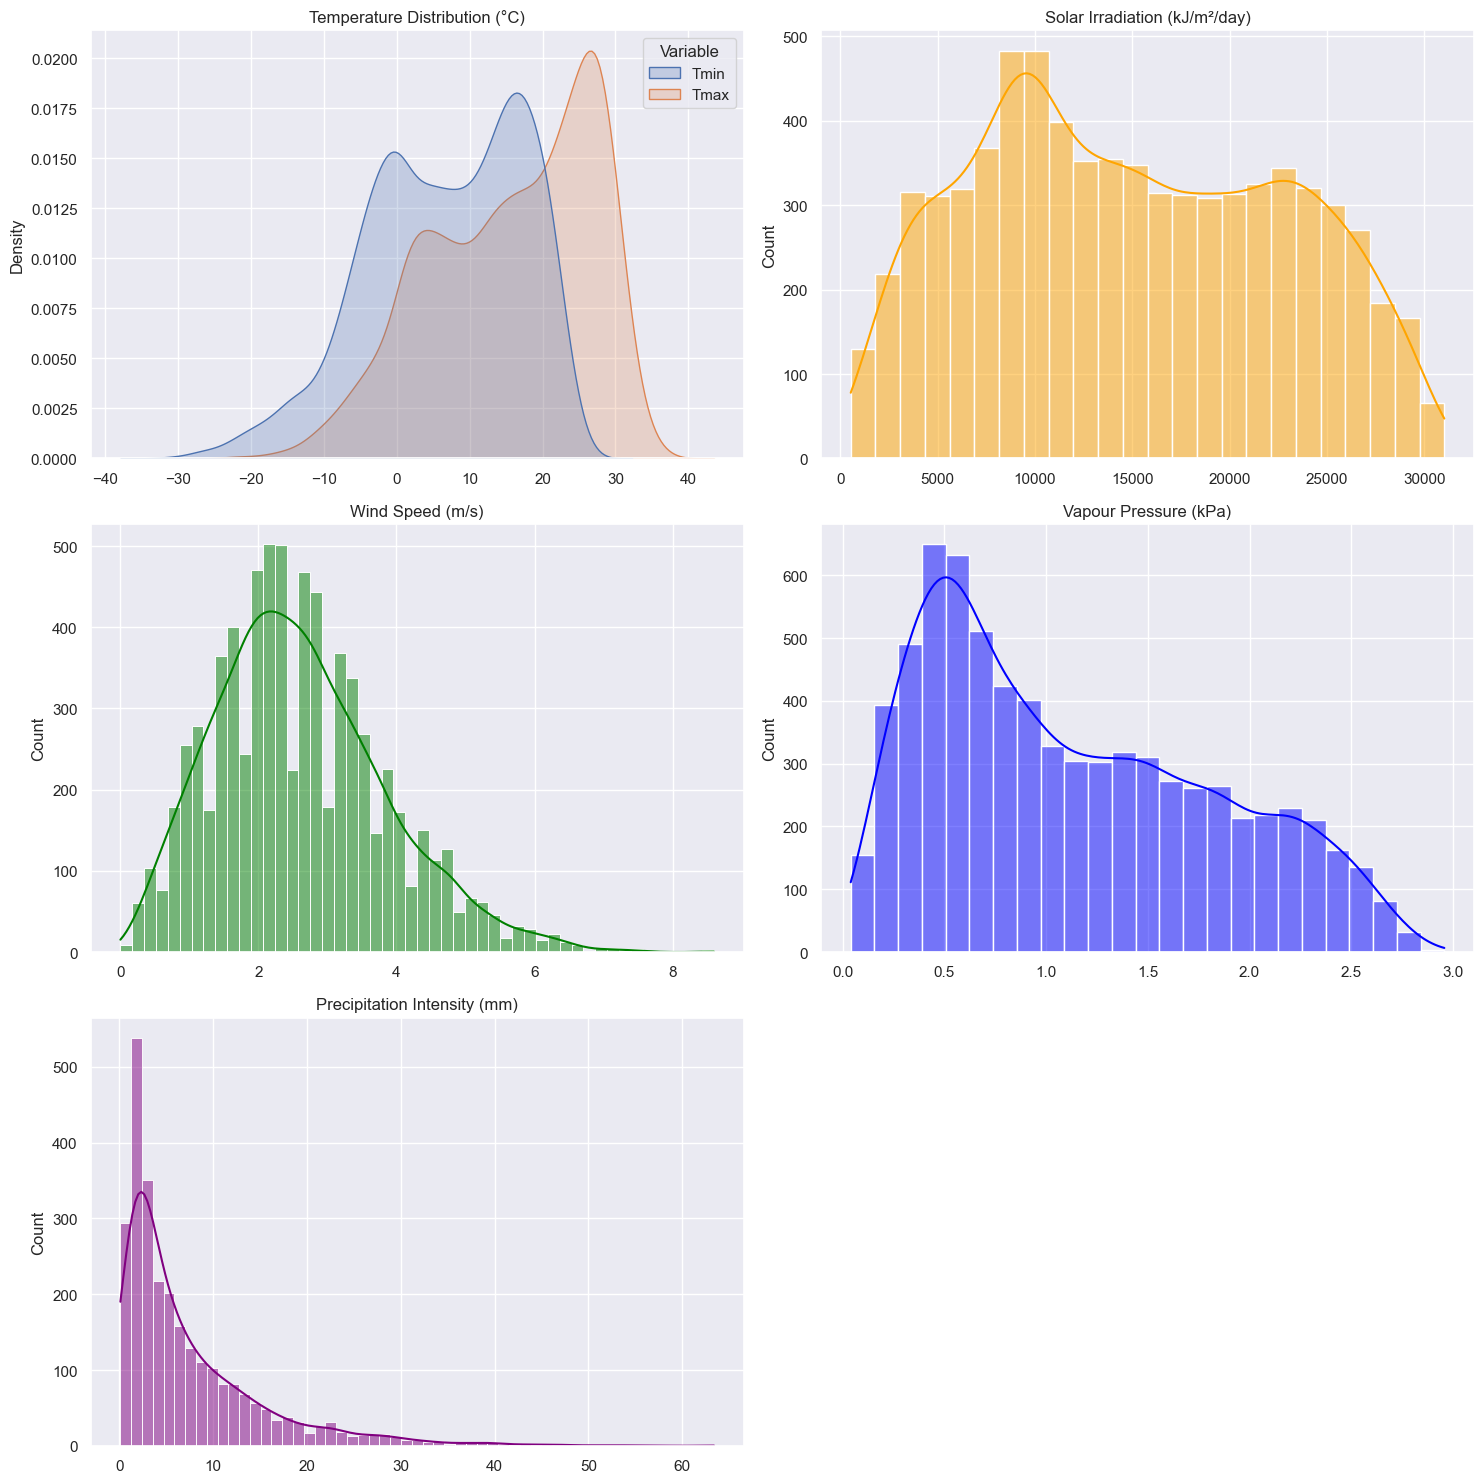

In [4]:
# Load the data
df_final = pd.read_csv(path_weather, sep='\t')
# Ensure the date column is recognized as a datetime object
df_final['date'] = pd.to_datetime(df_final['CURRENTDAY'], dayfirst=True)
plot_weather(
    df=df_final,
    columns=[['Tmin', 'Tmax'], 'Irradiation', 'WindSpeed', 'VapourPressure', 'Precipitation'],
    titles=['Temperature Distribution (°C)', 'Solar Irradiation (kJ/m²/day)', 'Wind Speed (m/s)', 'Vapour Pressure (kPa)', 'Precipitation Intensity (mm)'],
    colors=[None, 'orange', 'green', 'blue', 'purple'],
    filter_dict={'Precipitation': '> 0'}
)

### Converted (FraNchEstYN-format) weather file

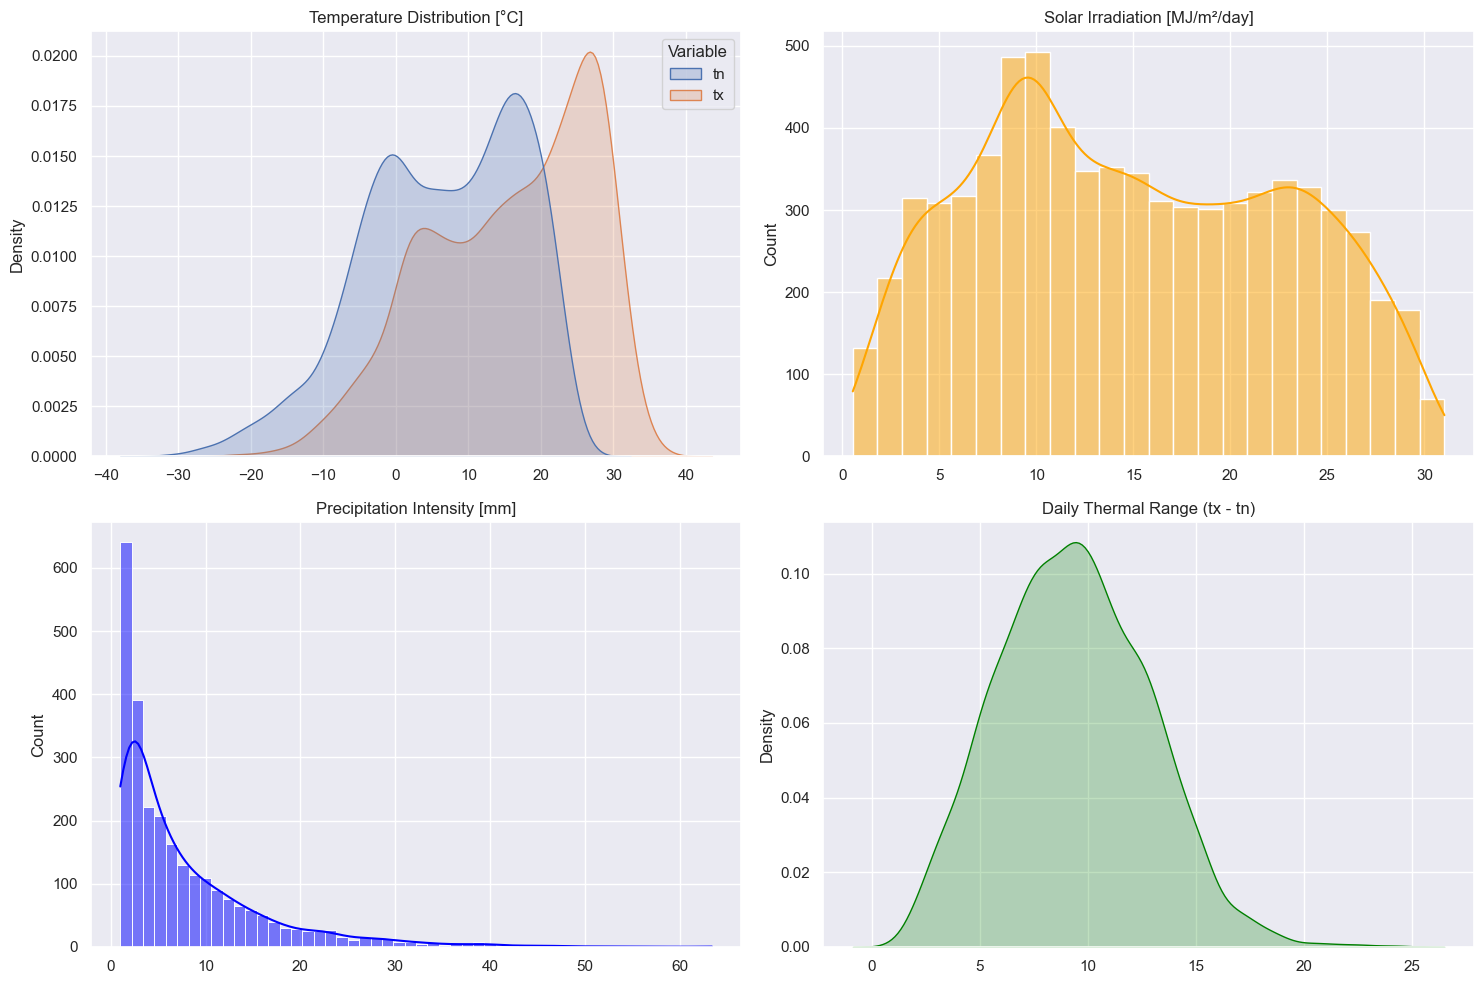

In [5]:
# 1. Load the "f" file (Comma-separated)
df_f = pd.read_csv(path_weather_f)

# 2. Create the date columns
df_f['date'] = pd.to_datetime(df_f[['year', 'month', 'day']])
df_f['DayOfYear'] = df_f['date'].dt.dayofyear
df_f['ThermalRange'] = df_f['tx'] - df_f['tn']

plot_weather(
    df=df_f,
    columns=[['tn', 'tx'], 'rad', 'p', 'ThermalRange'],
    titles=['Temperature Distribution [°C]', 'Solar Irradiation [MJ/m²/day]', 'Precipitation Intensity [mm]', 'Daily Thermal Range (tx - tn)'],
    colors=[None, 'orange', 'blue', 'green'],
    filter_dict={'p': '> 0'}
)


## 4. Stage 1 — Crop growth simulation

Run the SIMPLACE/Lintul5 solution to generate the daily crop trajectory. The runner returns the workspace and output directories, the selected project row, and the simulation date range, which drive the disease stage.

In [6]:
sp_cfg = simplace.SimplaceConfig(install_dir=SIMPLACE_INSTALL, work_dir=SIMPLACE_WORK, output_dir=SIMPLACE_OUT,solution_path=SOLUTION_PATH, project_path=PROJECT_PATH,)


# Stage 1: Run SIMPLACE only
shell = simplace.init_simplace(sp_cfg)
simplace.run_simplace(shell, sp_cfg, project_lines=PROJECT_LINES)

dirs = simplace.get_simplace_directories(shell)
work_root = Path(dirs["_WORKDIR_"])
output_root = Path(dirs["_OUTPUTDIR_"])
selected_line = PROJECT_LINES[0]
project_row = simplace.get_project_row(work_root, selected_line=selected_line)
simplace_daily_path = output_root / "SimulationExperimentTemplate" / f"{project_row['location']}{project_row['iopt']}_daily.csv"
start_year = int(project_row["startdate"].split(".")[-1])
end_year = int(project_row["enddate"].split(".")[-1])
print('SIMPLACE completed')
print('SIMPLACE daily output:', simplace_daily_path)


SIMPLACE completed
SIMPLACE daily output: data\simpest_outputs\SimulationExperimentTemplate\indiana4_daily.csv


### Crop model outputs

Visualise the daily crop-model variables grouped by process (growth, biomass and yield, water fluxes, radiation, and so on).

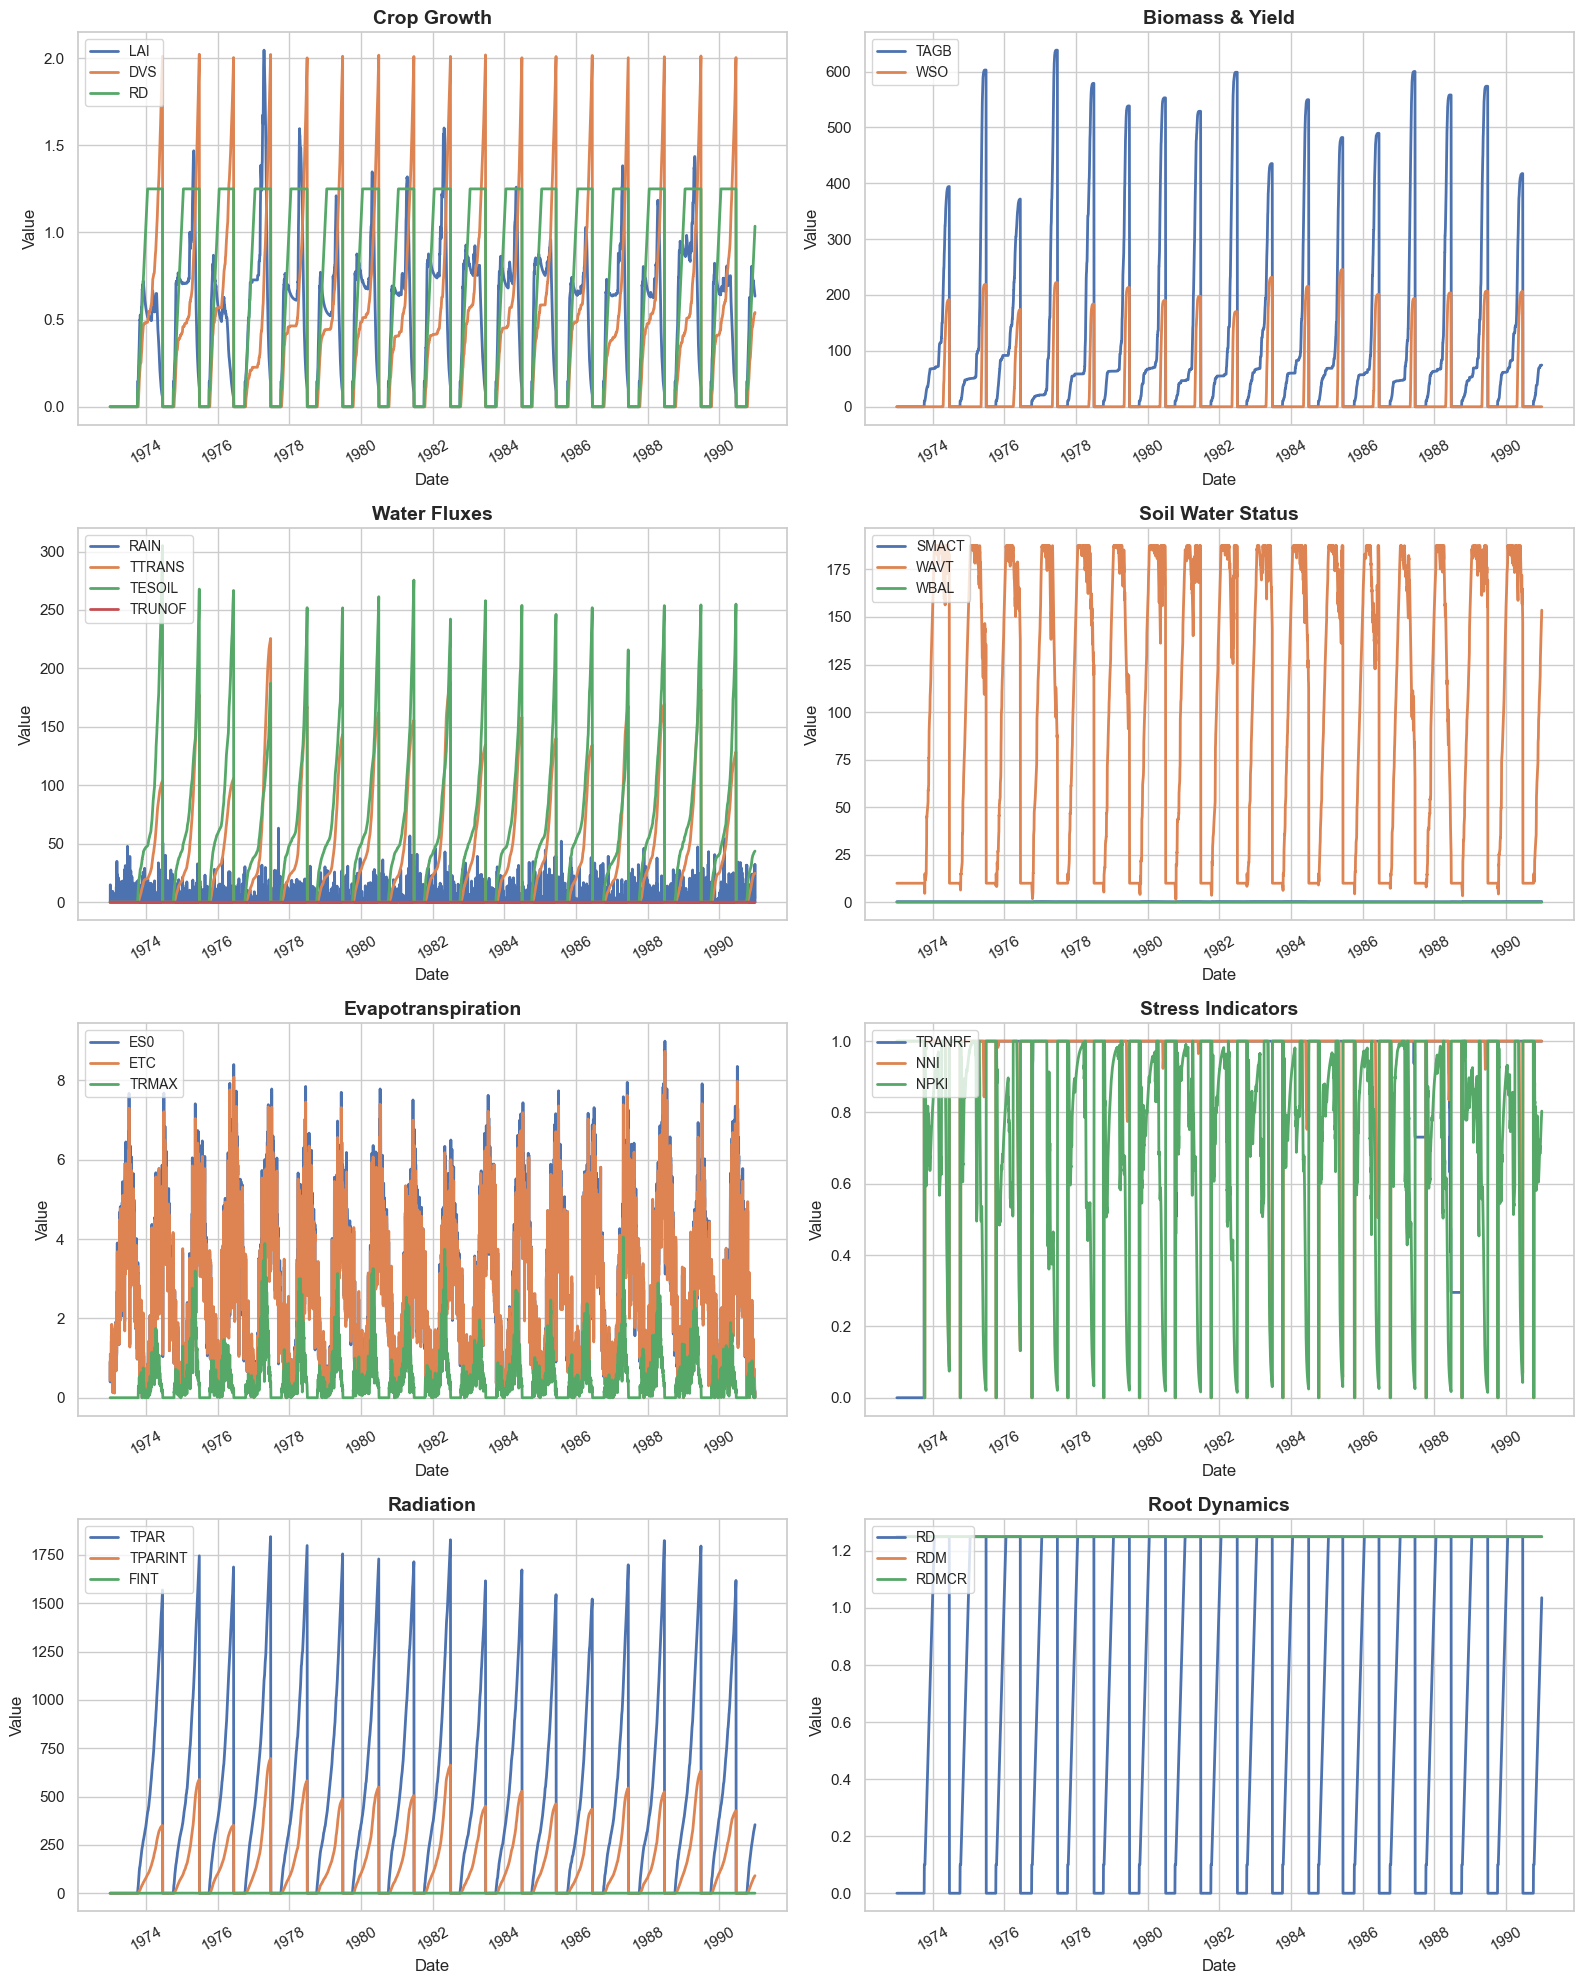

In [7]:
# Visualize SIMPLACE outputs (run after Stage 1)
sim_df = pd.read_csv(simplace_daily_path, sep=';')
sim_df['date'] = pd.to_datetime(sim_df['CURRENT.DATE'], format='%d.%m.%Y')
sim_df['TAGB'] = pd.to_numeric(sim_df['TAGB'], errors='coerce')
sim_df['WSO'] = pd.to_numeric(sim_df['WSO'], errors='coerce')

df = sim_df.copy()
df["date"] = pd.to_datetime(df["CURRENT.DATE"], dayfirst=True)

groups = [
    ("Crop Growth", ["LAI", "DVS", "RD"]),
    ("Biomass & Yield", ["TAGB", "WSO"]),
    ("Water Fluxes", ["RAIN", "TTRANS", "TESOIL", "TRUNOF"]),
    ("Soil Water Status", ["SMACT", "WAVT", "WBAL"]),
    ("Evapotranspiration", ["ES0", "ETC", "TRMAX"]),
    ("Stress Indicators", ["TRANRF", "NNI", "NPKI"]),
    ("Radiation", ["TPAR", "TPARINT", "FINT"]),
    ("Root Dynamics", ["RD", "RDM", "RDMCR"])
]

sns.set_theme(style="whitegrid")
n_groups = len(groups)
n_cols = 2
n_rows = (n_groups + 1) // n_cols  # Calculates rows needed for 2 columns

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()  # Flatten to easily iterate

for i, (title, variables) in enumerate(groups):
    ax = axes[i]
    
    # Plot each variable in the group
    for var in variables:
        if var in df.columns:
            sns.lineplot(data=df, x="date", y=var, ax=ax, label=var, linewidth=2)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Date")
    ax.set_ylabel("Value")
    ax.legend(loc='upper left', fontsize='small')
    
    # Rotate date labels for better readability
    plt.setp(ax.get_xticklabels(), rotation=30)

# Remove any empty subplots if the number of groups is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 5. Stage 2 — Disease simulation and calibration

Configure the FraNchEstYN runner and convert the SIMPLACE outputs into the crop-model, weather, and management inputs it expects. Selected parameters are excluded from calibration to keep the search focused.

In [8]:
# Parameter names to exclude from calibration
crop_disable = {"PartitioningMaximum", "TbaseCrop", "TmaxCrop", "ToptCrop", "FloweringStart", "RadiationUseEfficiency"}
disease_disable = {"RUEreducerDamage", "LightStealerDamage", "SenescenceAcceleratorDamage", "AssimilateSappersDamage"}


# crop_model_path = simplace.export_crop_model_data(output_root, project_row)
# weather_path = simplace.convert_weather(work_root, output_root, project_row["location"])
# management_path = simplace.build_management(output_root, project_row)

crop_model_path = "data/New/franchestyn_crop_model_data.csv" #simplace.export_crop_model_data(output_root, project_row)
weather_path =  "data/New/weather_indiana.csv" # simplace.convert_weather(work_root, output_root, project_row["location"])
management_path = "data/New/management_indiana.csv" # simplace.build_management(output_root, project_row)


crop_model_df = read_df(crop_model_path)
weather_df = read_df(weather_path)
management_df = read_df(management_path)
ref_df = read_df(path_reference_f)  # Assuming the reference file uses semicolon as delimiter


In [ ]:
# Exclusion is enforced by the optimizer using these sets.
fr_cfg = franchestyn.FranchestynConfig(
    # reference_df=ref_df,
    crop_type=FRANCH_CROP_TYPE,
    disease_type=FRANCH_DISEASE_TYPE,
    fungicide_type=FRANCH_FUNGICIDE_TYPE,
    site=FRANCH_SITE,
    variety=FRANCH_VARIETY,
    disease=FRANCH_DISEASE,
    is_calibration=FRANCH_IS_CALIBRATION,
    calibration_variable=FRANCH_CALIBRATION_VARIABLE,
    use_gdd=FRANCH_USE_GDD,
    use_prev_day_alignment=FRANCH_USE_PREV_DAY_ALIGNMENT,
    n_restarts=FRANCH_N_RESTARTS,
    max_iter=FRANCH_MAX_ITER,
    crop_disabled_params=frozenset(crop_disable),
    disease_disabled_params=frozenset(disease_disable),
)

### Inspect the management schedule

Check the generated management file, including any fungicide treatment columns.

### Run the disease model and calibration

Run FraNchEstYN with the SIMPLACE-derived inputs, save the daily results, season summary, and calibrated parameters, then merge the crop and disease outputs.

In [ ]:
# Stage 2: Run FraNchEstYN using in-memory DataFrame inputs
result = franchestyn.run_franchestyn(
    weather_df=weather_df,
    management_df=management_df,
    crop_model_df=crop_model_df,
    ref_df=ref_df,
    start_year=1973,  
    end_year=1991,   
    config=fr_cfg,
)

summary = result['outputs']['summary']
simulation = result['outputs']['simulation']

franchestyn.save_simulation_results_csv(simulation, output_root)
simulation_df = pd.DataFrame(simulation)
season_summary = franchestyn.build_season_summary(simulation_df, site=fr_cfg.site, variety=fr_cfg.variety)
franchestyn.save_season_summary_csv(season_summary, output_root)

best_params = summary.get('best_params', {}) if isinstance(summary, dict) else {}
franchestyn.save_calibrated_parameters_csv(
    best_params,
    output_root,
    site=fr_cfg.site,
    variety=fr_cfg.variety,
    config=fr_cfg,
    r_like=True,
)
merged_path = simplace.merge_simplace_and_franchestyn(output_root, project_row, simulation_df)

print('FraNchEstYN completed')
print('Merged output:', merged_path)
print('RMSE:', summary.get('rmse'))

Parsed row: site=indiana, year=1972, variety=generic, sow_doy=278, fung_doys=[]
Parsed row: site=indiana, year=1973, variety=generic, sow_doy=271, fung_doys=[]
Parsed row: site=indiana, year=1974, variety=generic, sow_doy=275, fung_doys=[]
Parsed row: site=indiana, year=1975, variety=generic, sow_doy=276, fung_doys=[]
Parsed row: site=indiana, year=1976, variety=generic, sow_doy=277, fung_doys=[]
Parsed row: site=indiana, year=1977, variety=generic, sow_doy=286, fung_doys=[]
Parsed row: site=indiana, year=1978, variety=generic, sow_doy=271, fung_doys=[]
Parsed row: site=indiana, year=1979, variety=generic, sow_doy=278, fung_doys=[]
Parsed row: site=indiana, year=1980, variety=generic, sow_doy=273, fung_doys=[]
Parsed row: site=indiana, year=1981, variety=generic, sow_doy=273, fung_doys=[]
Parsed row: site=indiana, year=1982, variety=generic, sow_doy=286, fung_doys=[]
Parsed row: site=indiana, year=1983, variety=generic, sow_doy=273, fung_doys=[]
Parsed row: site=indiana, year=1984, var

### Inspect the result tables

Load the merged daily output and the seasonal summary.

In [ ]:
# Final output tables (after Stage 2)
merged = pd.read_csv(merged_path)
summary_df = pd.read_csv(output_root / 'SimulationExperimentTemplate' / 'franchestyn_season_summary.csv')

print('Merged shape:', merged.shape)
print('Summary shape:', summary_df.shape)

## 6. Results visualization

Plot per-season panels of attainable vs. actual yield and biomass alongside simulated disease severity, with reference observations overlaid where available.

In [ ]:
print("Columns in merged DataFrame:")
print(merged.columns.tolist())
print("\nMerged shape:", merged.shape)
print("\nFirst few rows:")
print(merged.head())

In [ ]:
r_by_season = {}


r_path = Path('data/New/franchestyn_crop_model_data_w_disease.csv')

r_df = pd.read_csv(r_path)
r_df['date'] = pd.to_datetime(r_df['Date'], dayfirst=True, errors='coerce')

r_df = r_df.dropna(subset=['date']).sort_values('date')
r_df = r_df[r_df['date'].dt.month.isin([10, 11, 12, 1, 2, 3, 4, 5, 6, 7])].copy()
r_df['season_start_year'] = r_df['date'].dt.year.where(r_df['date'].dt.month >= 10, r_df['date'].dt.year - 1)
r_df['season_label'] = r_df['season_start_year'].astype(str) + '/' + (r_df['season_start_year'] + 1).astype(str)

for season, group in r_df.groupby('season_label', sort=True):
    r_by_season[season] = group.sort_values('date').copy()

print(f"Loaded {len(r_df)} R simulation points from {r_path} across seasons: {list(r_by_season.keys())}")




In [ ]:
# Load reference disease data
ref_df = None
ref_disease_by_season = {}
try:
    ref_path = Path(path_reference_f)
    if ref_path.exists():
        ref_df = pd.read_csv(ref_path)

        # Filter by site (case-insensitive) and variety
        if 'sName' in ref_df.columns:
            ref_df = ref_df[ref_df['sName'].str.lower() == FRANCH_SITE.lower()]
        if 'variety' in ref_df.columns:
            ref_df = ref_df[ref_df['variety'] == FRANCH_VARIETY]

        # Filter to rows with disease data
        ref_df = ref_df[ref_df[FRANCH_DISEASE].notna()].copy()

        if len(ref_df) > 0:
            # Map DOY + year to date
            ref_df['date'] = pd.to_datetime(
                ref_df['year'].astype(str) + ref_df['DOY'].astype(str),
                format='%Y%j',
                errors='coerce'
            )

            # Determine season for each reference point (Oct-Dec = current year season; Jan-Jul = previous year season)
            ref_df['season_start_year'] = ref_df['date'].dt.year.where(
                ref_df['date'].dt.month >= 10,
                ref_df['date'].dt.year - 1
            )
            ref_df['season_label'] = (
                ref_df['season_start_year'].astype(str) + '/' +
                (ref_df['season_start_year'] + 1).astype(str)
            )

            for season, group in ref_df.groupby('season_label'):
                ref_disease_by_season[season] = group[['date', FRANCH_DISEASE]].copy()
                ref_disease_by_season[season].columns = ['date', 'ref_disease']

        print(f"Loaded {len(ref_df)} reference disease points across seasons: {list(ref_disease_by_season.keys())}")
except Exception as e:
    print(f"Warning: Could not load reference data: {e}")

# Current Python simulation output
py_df = merged.copy()
py_df['date'] = pd.to_datetime(py_df['date'], errors='coerce')
py_df = py_df.dropna(subset=['date']).sort_values('date')
py_df = py_df[py_df['date'].dt.month.isin([10, 11, 12, 1, 2, 3, 4, 5, 6, 7])].copy()

# Season label: Oct-Dec belong to current year; Jan-Jul belong to previous-year season
py_df['season_start_year'] = py_df['date'].dt.year.where(py_df['date'].dt.month >= 10, py_df['date'].dt.year - 1)
py_df['season_label'] = py_df['season_start_year'].astype(str) + '/' + (py_df['season_start_year'] + 1).astype(str)

def pick_col(table, candidates):
    if table is None:
        return None
    for c in candidates:
        if c in table.columns:
            return c
    return None

# Python columns
yield_act_col = pick_col(py_df, ['YieldActual_F_kg_ha', 'YieldActual_F', 'YieldActual'])
yield_pot_col = pick_col(py_df, ['YieldAttainable_F_kg_ha', 'YieldAttainable_F', 'YieldAttainable'])
agb_act_col = pick_col(py_df, ['AGBactual_F', 'AGBactual'])
agb_pot_col = pick_col(py_df, ['AGBattainable_F', 'AGBattainable'])
disease_col = pick_col(py_df, ['DiseaseSeverity_F', 'DiseaseSeverity'])

# R columns
r_yield_act_col = pick_col(r_df, ['YieldActual', 'YieldActualRef'])
r_yield_pot_col = pick_col(r_df, ['YieldAttainable', 'YieldRef'])
r_agb_act_col = pick_col(r_df, ['AGBactual', 'AGBRef'])
r_agb_pot_col = pick_col(r_df, ['AGBattainable'])
r_disease_col = pick_col(r_df, ['DiseaseSeverity', 'DiseaseSeverityRef'])

missing = [
    ('actual yield', yield_act_col),
    ('potential yield', yield_pot_col),
    ('actual AGB', agb_act_col),
    ('potential AGB', agb_pot_col),
    ('disease severity', disease_col),
]
missing = [name for name, col in missing if col is None]
if missing:
    raise ValueError(f'Missing required columns for plotting: {missing}')

season_groups = [(s, g.sort_values('date').copy()) for s, g in py_df.groupby('season_label', sort=True)]
if not season_groups:
    raise ValueError('No data available in Oct-Jul window for plotting.')

n_cols = 3
n_rows = math.ceil(len(season_groups) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 4.2 * n_rows), squeeze=False)
axes_flat = axes.flatten()

for i, (season, g) in enumerate(season_groups):
    ax1 = axes_flat[i]
    ax2 = ax1.twinx()

    disease_series = pd.to_numeric(g[disease_col], errors='coerce')
    if disease_series.dropna().size > 0 and disease_series.dropna().max() <= 1.0:
        disease_series = disease_series * 100.0

    # Python simulation (solid lines)
    ax1.plot(g['date'], pd.to_numeric(g[yield_act_col], errors='coerce'), label='Yield Act (Py)', color='#1f77b4', linewidth=1.8)
    ax1.plot(g['date'], pd.to_numeric(g[yield_pot_col], errors='coerce'), label='Yield Pot (Py)', color='#17becf', linewidth=1.8, linestyle='--')
    ax1.plot(g['date'], pd.to_numeric(g[agb_act_col], errors='coerce'), label='AGB Act (Py)', color='#2ca02c', linewidth=1.8)
    ax1.plot(g['date'], pd.to_numeric(g[agb_pot_col], errors='coerce'), label='AGB Pot (Py)', color='#98df8a', linewidth=1.8, linestyle='--')
    ax2.plot(g['date'], disease_series, label='Disease Sim (Py)', color='#d62728', linewidth=1.8)

    # R simulation overlay (dotted lines)
    r_season = r_by_season.get(season) if r_by_season else None
    if r_season is not None and len(r_season) > 0:
        if r_yield_act_col is not None:
            ax1.plot(
                r_season['date'],
                pd.to_numeric(r_season[r_yield_act_col], errors='coerce'),
                label='Yield Act (R)',
                color='#1f77b4',
                linewidth=1.4,
                linestyle=':'
            )
        if r_yield_pot_col is not None:
            ax1.plot(
                r_season['date'],
                pd.to_numeric(r_season[r_yield_pot_col], errors='coerce'),
                label='Yield Pot (R)',
                color='#17becf',
                linewidth=1.4,
                linestyle=':'
            )
        if r_agb_act_col is not None:
            ax1.plot(
                r_season['date'],
                pd.to_numeric(r_season[r_agb_act_col], errors='coerce'),
                label='AGB Act (R)',
                color='#2ca02c',
                linewidth=1.4,
                linestyle=':'
            )
        if r_agb_pot_col is not None:
            ax1.plot(
                r_season['date'],
                pd.to_numeric(r_season[r_agb_pot_col], errors='coerce'),
                label='AGB Pot (R)',
                color='#98df8a',
                linewidth=1.4,
                linestyle=':'
            )
        if r_disease_col is not None:
            r_disease_series = pd.to_numeric(r_season[r_disease_col], errors='coerce')
            if r_disease_series.dropna().size > 0 and r_disease_series.dropna().max() <= 1.0:
                r_disease_series = r_disease_series * 100.0
            ax2.plot(
                r_season['date'],
                r_disease_series,
                label='Disease Sim (R)',
                color='#d62728',
                linewidth=1.4,
                linestyle=':'
            )

    # Overlay reference disease points if available for this season
    if season in ref_disease_by_season:
        ref_season = ref_disease_by_season[season]
        if len(ref_season) > 0:
            ref_disease_vals = pd.to_numeric(ref_season['ref_disease'], errors='coerce')
            if ref_disease_vals.max() <= 1.0:
                ref_disease_vals = ref_disease_vals * 100.0
            ax2.scatter(
                ref_season['date'],
                ref_disease_vals,
                marker='.',
                color='#d62728',
                s=10,
                linewidths=2.5,
                label='Disease Ref',
                zorder=10
            )

    ax1.set_title(f'Season {season}', fontsize=11, fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Yield/AGB (kg/ha)')
    ax2.set_ylabel('Disease (%)')
    ax1.grid(True, alpha=0.25)

    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    ax1.tick_params(axis='x', rotation=45)

    l1, t1 = ax1.get_legend_handles_labels()
    l2, t2 = ax2.get_legend_handles_labels()
    ax1.legend(l1 + l2, t1 + t2, loc='upper left', fontsize=8, frameon=True)

# Hide unused subplot panels
for j in range(len(season_groups), len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.show()